# CVAE - Lazazzara2018

# Etapa 3 

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DB_PATH = "../db/tfm_vocs.db"
PARQUET_PATH = "../db/data/processed/abundancias_lazazzara2018.csv"

In [2]:
import pickle
import numpy as np
from pathlib import Path

MODELS_DIR = Path("../models")

def export_cvae(dataset_slug, encoder, decoder, iso_forest, autoencoder,
                 scores_loo, errores_loo_ae, scaler, compound_ids, meta=None):
    out = MODELS_DIR / dataset_slug
    out.mkdir(parents=True, exist_ok=True)
    encoder.save(out / "cvae_encoder.keras")
    decoder.save(out / "cvae_decoder.keras")
    autoencoder.save(out / "autoencoder.keras")

    with open(out / "isolation_forest.pkl", "wb") as f:
        pickle.dump(iso_forest, f)
    with open(out / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open(out / "compound_ids.pkl", "wb") as f:
        pickle.dump(list(compound_ids), f)

    np.save(out / "scores_loo.npy", scores_loo)
    np.save(out / "errores_loo_ae.npy", errores_loo_ae)

    if meta:
        with open(out / "cvae_meta.pkl", "wb") as f:
            pickle.dump(meta, f)

    print(f"Exportado CVAE+detectores: {dataset_slug} -> {out}")

In [3]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

### Carga de datos

In [4]:
conn = sqlite3.connect(DB_PATH)

muestras = pd.read_sql(
    "SELECT sample_id, species, genotype, physiological_state, dataset_origin "
    "FROM muestras WHERE dataset_origin = 'Lazazzara2018'",
    conn
)
compuestos = pd.read_sql(
    "SELECT compuesto_id, pubchem_cid, name_original FROM compuestos WHERE dataset_origin = 'Lazazzara2018'",
    conn
)
conn.close()

voc = pd.read_csv(PARQUET_PATH)

print("Muestras:", muestras.shape)
print("Compuestos:", compuestos.shape)
print("Abundancias (formato largo):", voc.shape)
muestras.head()

Muestras: (98, 5)
Compuestos: (52, 3)
Abundancias (formato largo): (5096, 4)


,sample_id,species,genotype,physiological_state,dataset_origin
0,lazazzara2018_exp1_pinotnoir_0dpi_r01,Vitis vinifera / hibridos interespecificos,Pinot Noir,control,Lazazzara2018
1,lazazzara2018_exp1_pinotnoir_0dpi_r02,Vitis vinifera / hibridos interespecificos,Pinot Noir,control,Lazazzara2018
2,lazazzara2018_exp1_pinotnoir_0dpi_r03,Vitis vinifera / hibridos interespecificos,Pinot Noir,control,Lazazzara2018
3,lazazzara2018_exp1_pinotnoir_0dpi_r04,Vitis vinifera / hibridos interespecificos,Pinot Noir,control,Lazazzara2018
4,lazazzara2018_exp1_pinotnoir_0dpi_r05,Vitis vinifera / hibridos interespecificos,Pinot Noir,control,Lazazzara2018


### Preprocesamiento

In [5]:
# Excluir el contaminante detectado 
cid_contaminante = compuestos.loc[compuestos["pubchem_cid"] == 6782, "compuesto_id"]
voc_limpio = voc[~voc["compuesto_id"].isin(cid_contaminante)]

# Pivot 
wide = voc_limpio.pivot(index="sample_id", columns="compuesto_id", values="abundancia")
muestras_idx = muestras.set_index("sample_id").loc[wide.index]

# log1p
X_log = np.log1p(wide.values)
y_labels = muestras_idx["physiological_state"].values

print("X_log:", X_log.shape)

X_log: (98, 51)


In [6]:
# Dividir tr/ts
idx_train, idx_val = train_test_split(
    np.arange(len(X_log)), test_size=0.2, random_state=42, stratify=y_labels
)

In [7]:
# Estandarización
scaler = StandardScaler()
X_train = scaler.fit_transform(X_log[idx_train]).astype("float32")
X_val = scaler.transform(X_log[idx_val]).astype("float32")

In [8]:
# Dummies para la variable categorica 
y_dummies = pd.get_dummies(pd.Series(y_labels, name="physiological_state"), drop_first=True)
print("Columna de condicionamiento:", y_dummies.columns.tolist())

y_train = y_dummies.iloc[idx_train].values.astype("float32")
y_val = y_dummies.iloc[idx_val].values.astype("float32")

print("X_train:", X_train.shape, " X_val:", X_val.shape)
print("y_train:", y_train.shape, " y_val:", y_val.shape)

Columna de condicionamiento: ['infected']
X_train: (78, 51)  X_val: (20, 51)
y_train: (78, 1)  y_val: (20, 1)


### Encoder

In [9]:
input_dim = X_train.shape[1]   
cond_dim = y_train.shape[1]    
latent_dim = 2

#Encoder
x_in = layers.Input(shape=(input_dim,), name="x")
c_in = layers.Input(shape=(cond_dim,), name="condition")
h = layers.Concatenate()([x_in, c_in])
h = layers.Dense(16, activation="relu")(h)
h = layers.Dense(8, activation="relu")(h)

z_mean = layers.Dense(latent_dim, name="z_mean")(h)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(h)

def sampling(args):
    z_mean, z_log_var = args
    eps = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * eps

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

encoder = keras.Model([x_in, c_in], [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ x (InputLayer)                │ (None, 51)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ condition (InputLayer)        │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 52)                │               0 │ x[0][0], condition[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 16)                │             848 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 8)                 │             136 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              18 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              18 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z (Lambda)                    │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,020 (3.98 KB)

 Trainable params: 1,020 (3.98 KB)

 Non-trainable params: 0 (0.00 B)

### Decoder

In [10]:
# Decoder
z_in = layers.Input(shape=(latent_dim,), name="z_sample")
c_in2 = layers.Input(shape=(cond_dim,), name="condition_dec")
h_dec = layers.Concatenate()([z_in, c_in2])
h_dec = layers.Dense(8, activation="relu")(h_dec)
h_dec = layers.Dense(16, activation="relu")(h_dec)
x_out = layers.Dense(input_dim, activation="linear")(h_dec)

decoder = keras.Model([z_in, c_in2], x_out, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ z_sample (InputLayer)         │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ condition_dec (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 3)                 │               0 │ z_sample[0][0],            │
│                               │                           │                 │ condition_dec[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 8)                 │              32 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 16)                │             144 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 51)                │             867 │ dense_3[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,043 (4.07 KB)

 Trainable params: 1,043 (4.07 KB)

 Non-trainable params: 0 (0.00 B)

### CVAE completo

In [11]:
class CVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = tf.Variable(0.0, trainable=False, dtype=tf.float32)
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        x, c = inputs
        _, _, z = self.encoder([x, c])
        return self.decoder([z, c])

    def _compute_losses(self, x, c):
        z_mean, z_log_var, z = self.encoder([x, c])
        x_recon = self.decoder([z, c])
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - x_recon), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        (x, c), _ = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x, c)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (x, c), _ = data
        total_loss, recon_loss, kl_loss = self._compute_losses(x, c)
        self.loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


cvae = CVAE(encoder, decoder)

### Entrenamiento

In [12]:
class KLWarmup(keras.callbacks.Callback):

    def __init__(self, cvae, warmup_epochs=50, max_beta=1.0):
        super().__init__()
        self.cvae = cvae
        self.warmup_epochs = warmup_epochs
        self.max_beta = max_beta

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = self.max_beta * min(1.0, epoch / self.warmup_epochs)
        self.cvae.beta.assign(new_beta)


cvae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))
warmup_cb = KLWarmup(cvae, warmup_epochs=50, max_beta=1.0)

history = cvae.fit(
    x=(X_train, y_train), y=X_train,
    validation_data=((X_val, y_val), X_val),
    epochs=800, batch_size=16,
    callbacks=[warmup_cb], verbose=1
)

Epoch 1/800
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - kl_loss: 1.9140 - loss: 60.2086 - recon_loss: 60.2086 - val_kl_loss: 1.8087 - val_loss: 59.7088 - val_recon_loss: 59.7088
Epoch 2/800
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - kl_loss: 1.4852 - loss: 56.1597 - recon_loss: 56.1300 - val_kl_loss: 1.4899 - val_loss: 58.8622 - val_recon_loss: 58.8324
Epoch 3/800
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - kl_loss: 1.2063 - loss: 54.0098 - recon_loss: 53.9616 - val_kl_loss: 1.2632 - val_loss: 57.1859 - val_recon_loss: 57.1354
Epoch 4/800
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - kl_loss: 1.0187 - loss: 53.7367 - recon_loss: 53.6756 - val_kl_loss: 1.0917 - val_loss: 57.7044 - val_recon_loss: 57.6389
Epoch 5/800
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - kl_loss: 0.8841 - loss: 52.7836 - recon_loss: 52.7129 - val_kl_loss: 0.9740 - val_loss: 56.6523 - val_recon_loss: 56.5744
Epoch 6/800
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - kl_loss: 0.7906 - loss: 52.7065 - recon_loss: 52.6274 - val_kl_loss: 0.8879 - 

### Curva de pérdida

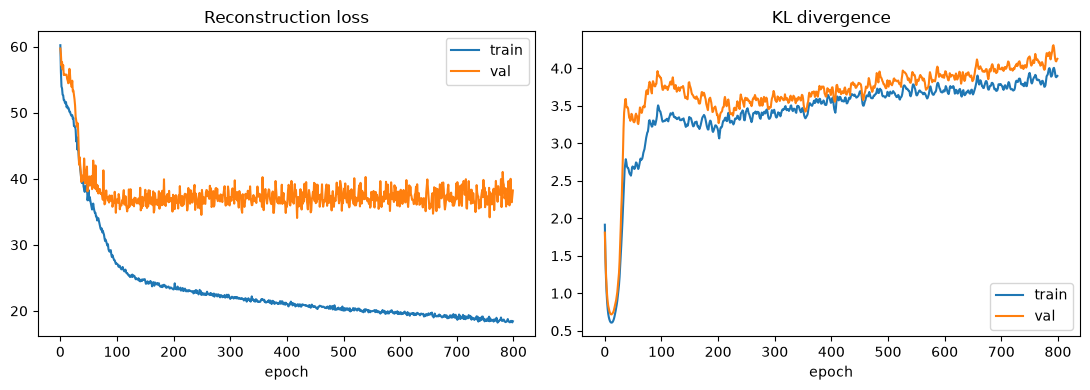

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["recon_loss"], label="train")
axes[0].plot(history.history["val_recon_loss"], label="val")
axes[0].set_title("Reconstruction loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["kl_loss"], label="train")
axes[1].plot(history.history["val_kl_loss"], label="val")
axes[1].set_title("KL divergence")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

### Chqueo de reconstrucción

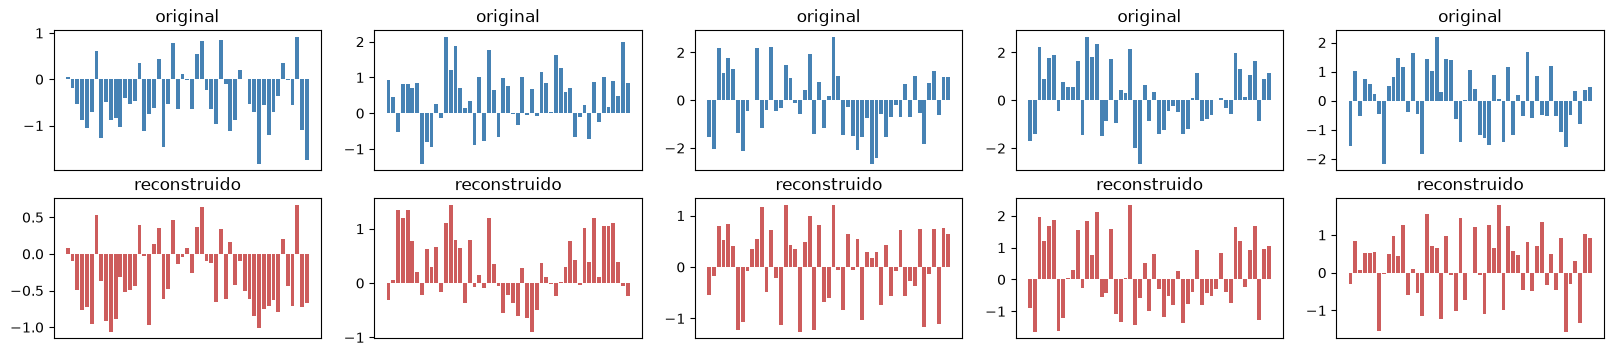

In [14]:
n = 5
x_sample = X_val[:n]
c_sample = y_val[:n]
x_recon = cvae((x_sample, c_sample)).numpy()

plt.figure(figsize=(20, 4))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.bar(range(X_val.shape[1]), x_sample[i], color="steelblue")
    plt.title("original")
    ax.get_xaxis().set_visible(False)

    # reconstruido
    ax = plt.subplot(2, n, i + 1 + n)
    plt.bar(range(X_val.shape[1]), x_recon[i], color="indianred")
    plt.title("reconstruido")
    ax.get_xaxis().set_visible(False)
plt.show()

### Espacio latente

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


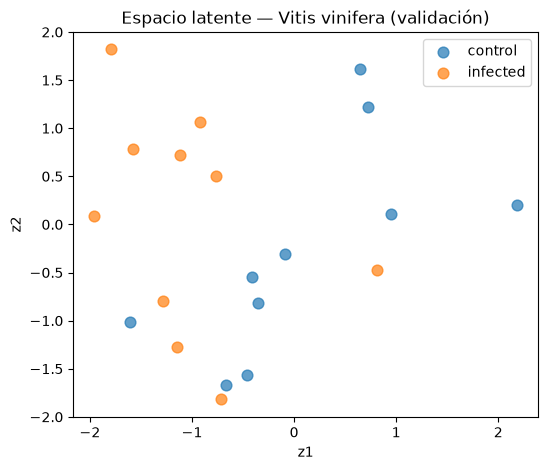

Silhouette score (validación): 0.10981275886297226


In [15]:
from sklearn.metrics import silhouette_score

# Codificar las muestras de validación
z_mean_val, _, _ = encoder.predict([X_val, y_val])

labels_val = y_val[:, 0].astype(int)

plt.figure(figsize=(6, 5))
plt.scatter(z_mean_val[labels_val == 0, 0], z_mean_val[labels_val == 0, 1], label="control", alpha=0.7, s=60)
plt.scatter(z_mean_val[labels_val == 1, 0], z_mean_val[labels_val == 1, 1], label="infected", alpha=0.7, s=60)
plt.xlabel("z1")
plt.ylabel("z2")
plt.legend()
plt.title("Espacio latente — Vitis vinifera (validación)")
plt.show()

sil = silhouette_score(z_mean_val, labels_val)
print("Silhouette score (validación):", sil)

### Exploración del gradiente

In [16]:
# Punto de referencia en el espacio latente
z_fixed = np.zeros((1, latent_dim))

# Interpolación de la condición: 0 (control) a 1 (infected)
n_steps = 11
c_steps = np.linspace(0, 1, n_steps).reshape(-1, 1)
z_repeated = np.repeat(z_fixed, n_steps, axis=0)

perfiles_generados = decoder.predict([z_repeated, c_steps])

# Cuanto cambia cada compuesto entre el extremo control y el infected 
delta = perfiles_generados[-1] - perfiles_generados[0]

compound_ids = wide.columns
cambios = pd.DataFrame({"compuesto_id": compound_ids, "delta": delta})
cambios = cambios.merge(compuestos[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
cambios = cambios.reindex(cambios["delta"].abs().sort_values(ascending=False).index)

print("Top 10 compuestos que más cambian en el trayecto 0 a 1:")
cambios.head(10)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Top 10 compuestos que más cambian en el trayecto 0 a 1:


,compuesto_id,delta,name_original,pubchem_cid
31,lazazzara2018_cmp033,-0.788064,2-Pentylfuran (vitis stem_pomace)_18,19602.0
26,lazazzara2018_cmp028,-0.757504,Benzeneacetaldehyde (vitis berry_stem)_26,998.0
6,lazazzara2018_cmp007,0.746754,beta-Myrcene (vitis berry)_115,31253.0
50,lazazzara2018_cmp052,-0.740718,No match: 1681.58_C21-C40_574,NaN
40,lazazzara2018_cmp042,-0.702899,No match: 1443.42_C21-C40_1020,NaN
28,lazazzara2018_cmp030,0.695010,2_4-Hexadienal (E_E)-_14,637564.0
45,lazazzara2018_cmp047,0.680112,No match: 1528.61_Solaris 6dpi_01_363,NaN
42,lazazzara2018_cmp044,-0.679920,No match: 1469.42_C21-C40_828_2,NaN
15,lazazzara2018_cmp016,0.660157,Tetradecanal_05,31291.0
48,lazazzara2018_cmp050,0.659332,No match: 1556.05_BC4 0dpi_1_722,NaN


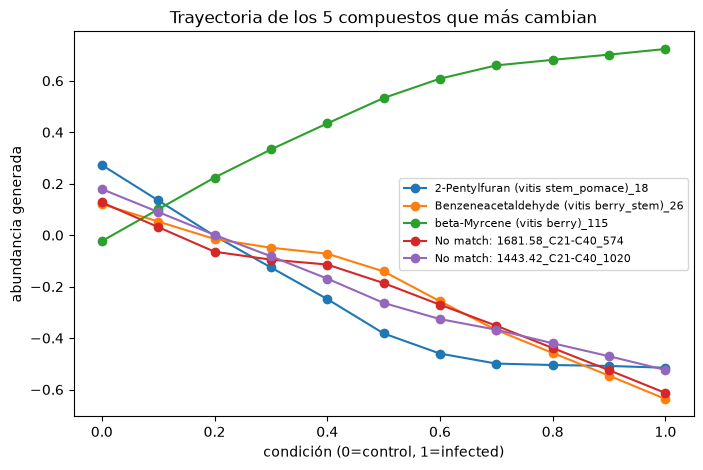

In [17]:
top5 = cambios.head(5)["compuesto_id"].tolist()
idx_top5 = [list(compound_ids).index(cid) for cid in top5]

plt.figure(figsize=(8, 5))
for i, cid in zip(idx_top5, top5):
    nombre = compuestos.loc[compuestos["compuesto_id"] == cid, "name_original"].values
    etiqueta = nombre[0] if len(nombre) else cid
    plt.plot(c_steps.flatten(), perfiles_generados[:, i], marker="o", label=etiqueta)

plt.xlabel("condición (0=control, 1=infected)")
plt.ylabel("abundancia generada")
plt.legend(fontsize=8)
plt.title("Trayectoria de los 5 compuestos que más cambian")
plt.show()

# Etapa 4

In [18]:
# Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import LeaveOneOut

SEED = 42

# Pool de datos usados
X_real = np.vstack([X_train, X_val])
n_real = X_real.shape[0]
print(f"Muestras disponibles para calibrar el detector: {n_real}")

# Detector final
iso_final = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
iso_final.fit(X_real)

# score_samples. Más alto será más normal
score_generados = -iso_final.score_samples(perfiles_generados)

# Calibración leave-one-out
loo = LeaveOneOut()
scores_loo = np.zeros(n_real)
for train_idx, test_idx in loo.split(X_real):
    iso_fold = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
    iso_fold.fit(X_real[train_idx])
    scores_loo[test_idx[0]] = -iso_fold.score_samples(X_real[test_idx])[0]

print("\nDistribución LOO de scores en muestras reales (vid):")
print(pd.Series(scores_loo).describe())

Muestras disponibles para calibrar el detector: 98

Distribución LOO de scores en muestras reales (vid):
count    98.000000
mean      0.468846
std       0.035272
min       0.405399
25%       0.439329
50%       0.467366
75%       0.485832
max       0.565049
dtype: float64


In [19]:
# % de la distrib de referncia queda debajo de score 
def percentil_vs_referencia(score, referencia):
    return (referencia < score).mean() * 100

percentiles = np.array([percentil_vs_referencia(s, scores_loo) for s in score_generados])

resultado_vid = pd.DataFrame({
    "paso_condicion": c_steps.flatten(), 
    "score_isolation_forest": score_generados,
    "percentil_vs_reales": percentiles,
})
resultado_vid

,paso_condicion,score_isolation_forest,percentil_vs_reales
0,0.0,0.390487,0.000000
1,0.1,0.392721,0.000000
2,0.2,0.393975,0.000000
3,0.3,0.397440,0.000000
4,0.4,0.394946,0.000000
5,0.5,0.393917,0.000000
6,0.6,0.396983,0.000000
7,0.7,0.397077,0.000000
8,0.8,0.397396,0.000000
9,0.9,0.404154,0.000000


In [20]:
# Extrapolación para ver mas allá en una condición mayor a infected.
n_steps_extra = 11
c_steps_extra = np.linspace(1.0, 2.0, n_steps_extra).reshape(-1, 1)
z_repeated_extra = np.repeat(z_fixed, n_steps_extra, axis=0)

perfiles_extrapolados = decoder.predict([z_repeated_extra, c_steps_extra])

score_extrapolados = -iso_final.score_samples(perfiles_extrapolados)
percentiles_extrapolados = np.array(
    [percentil_vs_referencia(s, scores_loo) for s in score_extrapolados]
)

resultado_extrapolado = pd.DataFrame({
    "paso_condicion": c_steps_extra.flatten(),
    "score_isolation_forest": score_extrapolados,
    "percentil_vs_reales": percentiles_extrapolados,
})
resultado_extrapolado

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


,paso_condicion,score_isolation_forest,percentil_vs_reales
0,1.0,0.409258,2.040816
1,1.1,0.414150,3.061224
2,1.2,0.420682,6.122449
3,1.3,0.427101,9.183673
4,1.4,0.431839,14.285714
5,1.5,0.434092,17.346939
6,1.6,0.435917,21.428571
7,1.7,0.440463,25.510204
8,1.8,0.446067,29.591837
9,1.9,0.455369,37.755102


In [21]:
# Detector no condicional, independiente del CVAE
def build_autoencoder(input_dim, bottleneck=4):
    inputs = tf.keras.Input(shape=(input_dim,))
    encoded = layers.Dense(16, activation="relu")(inputs)
    encoded = layers.Dense(8, activation="relu")(encoded)
    encoded = layers.Dense(bottleneck, activation="relu")(encoded)
    decoded = layers.Dense(8, activation="relu")(encoded)
    decoded = layers.Dense(16, activation="relu")(decoded)
    decoded = layers.Dense(input_dim, activation="linear")(decoded)
    ae = tf.keras.Model(inputs, decoded)
    ae.compile(optimizer="adam", loss="mse")
    return ae

def recon_error(model, X):
    X_hat = model.predict(X, verbose=0)
    return np.mean((X - X_hat) ** 2, axis=1)

AE_EPOCHS = 150
AE_BATCH = 8

# Detector final
ae_final = build_autoencoder(X_real.shape[1])
ae_final.fit(X_real, X_real, epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)

error_generados_ae = recon_error(ae_final, perfiles_generados)
error_extrapolados_ae = recon_error(ae_final, perfiles_extrapolados)

# Calibración LOO
loo = LeaveOneOut()
errores_loo_ae = np.zeros(n_real)
for train_idx, test_idx in loo.split(X_real):
    ae_fold = build_autoencoder(X_real.shape[1])
    ae_fold.fit(X_real[train_idx], X_real[train_idx], epochs=AE_EPOCHS, batch_size=AE_BATCH, verbose=0)
    errores_loo_ae[test_idx[0]] = recon_error(ae_fold, X_real[test_idx])[0]

print("Distribución LOO de error de reconstrucción en muestras reales (vid):")
print(pd.Series(errores_loo_ae).describe())

Distribución LOO de error de reconstrucción en muestras reales (vid):
count    98.000000
mean      0.551109
std       0.286739
min       0.115653
25%       0.358470
50%       0.502656
75%       0.678928
max       2.136209
dtype: float64


In [22]:
# Resumen
resultado_vid["percentil_ae_vs_reales"] = [
    percentil_vs_referencia(e, errores_loo_ae) for e in error_generados_ae
]
resultado_extrapolado["percentil_ae_vs_reales"] = [
    percentil_vs_referencia(e, errores_loo_ae) for e in error_extrapolados_ae
]

resultado_vid

,paso_condicion,score_isolation_forest,percentil_vs_reales,percentil_ae_vs_reales
0,0.0,0.390487,0.000000,0.0
1,0.1,0.392721,0.000000,0.0
2,0.2,0.393975,0.000000,0.0
3,0.3,0.397440,0.000000,0.0
4,0.4,0.394946,0.000000,0.0
5,0.5,0.393917,0.000000,0.0
6,0.6,0.396983,0.000000,0.0
7,0.7,0.397077,0.000000,0.0
8,0.8,0.397396,0.000000,0.0
9,0.9,0.404154,0.000000,0.0


In [23]:
resultado_extrapolado

,paso_condicion,score_isolation_forest,percentil_vs_reales,percentil_ae_vs_reales
0,1.0,0.409258,2.040816,0.000000
1,1.1,0.414150,3.061224,0.000000
2,1.2,0.420682,6.122449,0.000000
3,1.3,0.427101,9.183673,1.020408
4,1.4,0.431839,14.285714,3.061224
5,1.5,0.434092,17.346939,3.061224
6,1.6,0.435917,21.428571,6.122449
7,1.7,0.440463,25.510204,9.183673
8,1.8,0.446067,29.591837,13.265306
9,1.9,0.455369,37.755102,22.448980


In [24]:
# Falso + para corroborar

z_extremo = np.full((1, latent_dim), 5.0)
c_extremo = np.array([[1.0]]) 

perfil_control_positivo = decoder.predict([z_extremo, c_extremo])

score_if_control = -iso_final.score_samples(perfil_control_positivo)[0]
error_ae_control = recon_error(ae_final, perfil_control_positivo)[0]

print("Control positivo (z extremo):")
print(f"  Score Isolation Forest: {score_if_control:.4f}  (percentil {percentil_vs_referencia(score_if_control, scores_loo):.1f}%)")
print(f"  Error autoencoder:      {error_ae_control:.4f}  (percentil {percentil_vs_referencia(error_ae_control, errores_loo_ae):.1f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Control positivo (z extremo):
  Score Isolation Forest: 0.5828  (percentil 100.0%)
  Error autoencoder:      3.2404  (percentil 100.0%)


In [25]:
# Clasificación final - plausible / frontera / novedoso 
def clasificar(perc_if, perc_ae=None):
    percentiles = [p for p in [perc_if, perc_ae] if p is not None]
    if all(p > 97.5 for p in percentiles):
        return "novedoso"
    elif all(p < 90 for p in percentiles):
        return "plausible"
    else:
        return "frontera"

resultado_vid["clasificacion"] = [
    clasificar(row.percentil_vs_reales, row.percentil_ae_vs_reales)
    for row in resultado_vid.itertuples()
]
resultado_extrapolado["clasificacion"] = [
    clasificar(row.percentil_vs_reales, row.percentil_ae_vs_reales)
    for row in resultado_extrapolado.itertuples()
]

print("Gradiente observado (control a infected):")
print(resultado_vid[["paso_condicion", "clasificacion"]])
print("\nExtrapolación (infected a 2x infected):")
print(resultado_extrapolado[["paso_condicion", "clasificacion"]])

Gradiente observado (control a infected):
    paso_condicion clasificacion
0              0.0     plausible
1              0.1     plausible
2              0.2     plausible
3              0.3     plausible
4              0.4     plausible
5              0.5     plausible
6              0.6     plausible
7              0.7     plausible
8              0.8     plausible
9              0.9     plausible
10             1.0     plausible

Extrapolación (infected a 2x infected):
    paso_condicion clasificacion
0              1.0     plausible
1              1.1     plausible
2              1.2     plausible
3              1.3     plausible
4              1.4     plausible
5              1.5     plausible
6              1.6     plausible
7              1.7     plausible
8              1.8     plausible
9              1.9     plausible
10             2.0     plausible


In [26]:
export_cvae(
    "lazazzara2018",
    encoder=encoder, decoder=decoder, iso_forest=iso_final, autoencoder=ae_final,
    scores_loo=scores_loo, errores_loo_ae=errores_loo_ae, scaler=scaler, compound_ids=compound_ids,
    meta={"especie": "Vitis vinifera"}
)

Exportado CVAE+detectores: lazazzara2018 -> ..\models\lazazzara2018
